# Image Classification with a Convolutional Neural Network

## Introduction
This notebook introduces image classification with a small convolutional neural network (CNN) in PyTorch. The workflow covers data loading, visualization, model definition, training, evaluation, and a light refinement experiment.

## Project Goal
Train a CNN on an image dataset, understand the purpose of each part of the PyTorch pipeline, and compare the baseline model against a small refinement.

## Machine Learning Concepts Used
- Deep Learning
- Convolutional Neural Networks
- PyTorch
- DataLoader
- Training Loop
- Evaluation Mode
- Image Normalization
- Light Refinement

## Dataset
`torchvision.datasets.MNIST`

## Step 1: Import libraries

**What this section is doing**  
Import the PyTorch and torchvision components required for image loading, batching, model building, optimization, and plotting.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import pandas as pd

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## Step 2: Load and transform the dataset

**What this section is doing**  
Define a transform pipeline and load the train and test splits. DataLoaders handle batching and shuffling automatically.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("Train size:", len(train_dataset))
print("Test size :", len(test_dataset))

100%|██████████| 9.91M/9.91M [00:00<00:00, 60.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.63MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 13.9MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.72MB/s]


Train size: 60000
Test size : 10000


## Step 3: Inspect sample images

**What this section is doing**  
Visualizing sample images confirms that the dataset loaded correctly and keeps the modeling task concrete.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

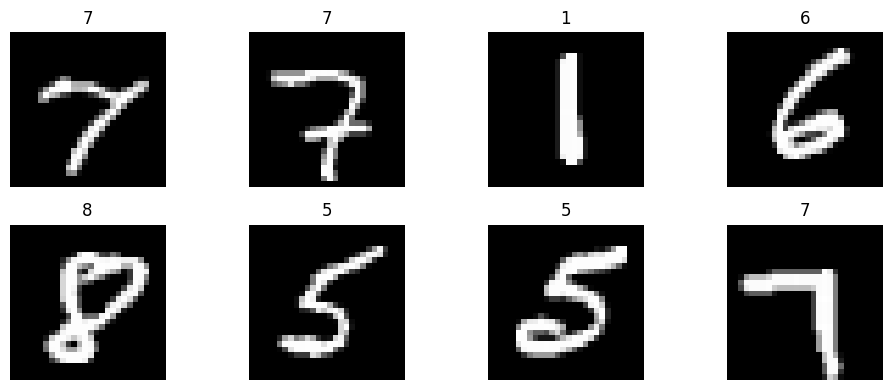

In [3]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 4))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title(int(labels[i]))
    plt.axis("off")
plt.tight_layout()
plt.show()

## Step 4: Define the CNN architecture

**What this section is doing**  
A CNN uses convolution and pooling layers to preserve spatial information while gradually learning useful image patterns.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

In [4]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(model)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


## Step 5: Train the baseline CNN

**What this section is doing**  
The training loop iterates over image batches, computes predictions, evaluates loss, backpropagates gradients, and updates the parameters.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

In [5]:
epochs = 3
history = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for batch_images, batch_labels in train_loader:
        batch_images = batch_images.to(device)
        batch_labels = batch_labels.to(device)

        optimizer.zero_grad()
        outputs = model(batch_images)
        loss = criterion(outputs, batch_labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    history.append({"epoch": epoch + 1, "train_loss": avg_loss})
    print(f"Epoch {epoch + 1}/{epochs} - Loss: {avg_loss:.4f}")

Epoch 1/3 - Loss: 0.1819
Epoch 2/3 - Loss: 0.0526
Epoch 3/3 - Loss: 0.0380


## Step 6: Inspect training history

**What this section is doing**  
Even a simple training-history table is useful because it shows whether the model is learning in the expected direction.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

In [6]:
history_df = pd.DataFrame(history)
display(history_df)

,epoch,train_loss
0,1,0.181907
1,2,0.052612
2,3,0.038019


## Step 7: Evaluate the CNN on the test set

**What this section is doing**  
Switch the model to evaluation mode and measure accuracy on unseen test images.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

In [7]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for batch_images, batch_labels in test_loader:
        batch_images = batch_images.to(device)
        batch_labels = batch_labels.to(device)

        outputs = model(batch_images)
        _, predicted = torch.max(outputs, 1)

        total += batch_labels.size(0)
        correct += (predicted == batch_labels).sum().item()

test_accuracy = correct / total
print(f"Baseline test accuracy: {test_accuracy:.4f}")

Baseline test accuracy: 0.9870


## Step 8: Refine the model lightly

**What this section is doing**  
Instead of changing the full architecture, perform one light refinement by training for one additional epoch and compare the test result. For CNNs, refinement often means architecture or training changes rather than classical feature selection.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

In [8]:
for extra_epoch in range(1):
    model.train()
    running_loss = 0.0

    for batch_images, batch_labels in train_loader:
        batch_images = batch_images.to(device)
        batch_labels = batch_labels.to(device)

        optimizer.zero_grad()
        outputs = model(batch_images)
        loss = criterion(outputs, batch_labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    print(f"Extra epoch loss: {avg_loss:.4f}")

model.eval()
correct_refined = 0
total_refined = 0

with torch.no_grad():
    for batch_images, batch_labels in test_loader:
        batch_images = batch_images.to(device)
        batch_labels = batch_labels.to(device)

        outputs = model(batch_images)
        _, predicted = torch.max(outputs, 1)

        total_refined += batch_labels.size(0)
        correct_refined += (predicted == batch_labels).sum().item()

refined_accuracy = correct_refined / total_refined

comparison_df = pd.DataFrame({
    "model_version": ["baseline_3_epochs", "refined_4_epochs"],
    "test_accuracy": [test_accuracy, refined_accuracy]
})

display(comparison_df)

Extra epoch loss: 0.0291


,model_version,test_accuracy
0,baseline_3_epochs,0.9870
1,refined_4_epochs,0.9894


## Step 9: Final analysis and next steps

**What this section is doing**  
Conclude by explaining why CNNs are suited to image data, what the refinement changed, and which improvements would matter most in a stronger version.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

### Final Analysis

Convolutional Neural Networks (CNNs) are particularly well-suited for image classification tasks because their architecture is designed to process pixel data effectively. Convolutional layers can automatically learn hierarchical features from images, such as edges, textures, and patterns, by applying filters across the input. Pooling layers then reduce the spatial dimensions, making the model more robust to variations in position and scale, and reducing computational complexity without losing critical information. This approach is superior to simply flattening image data and feeding it into a fully connected network, as it preserves the crucial spatial relationships between pixels.

The simple refinement, which involved training the model for one additional epoch, resulted in a slight but noticeable improvement in test accuracy. The baseline model achieved an accuracy of `0.9870` after 3 epochs, while the refined model reached `0.9894` after 4 epochs. This indicates that the model was still learning and generalizing slightly better with more training time in this specific scenario.

### Next Steps

To further improve the model and ensure its robustness, several next steps could be taken:

-   **Add a validation set**: This would allow for monitoring model performance during training and help in preventing overfitting.
-   **Tune learning rate and batch size**: Hyperparameter optimization can significantly impact model convergence and final performance.
-   **Try more filters or data augmentation**: Expanding the model's capacity or artificially increasing the diversity of the training data can lead to better generalization.
-   **Inspect per-class accuracy and confusion patterns**: Understanding which classes the model struggles with can guide targeted improvements.
